In [1]:
from typing import TypedDict

from langgraph.constants import START,END
from langgraph.graph import StateGraph
from model import qwen

In [2]:
class AgentState(TypedDict):
    summary: str
    entities: str
    search_result: str

In [3]:
graph = StateGraph(AgentState)
llm = qwen

In [4]:
# ======================
# 3 个并行节点
# ======================
def summary_action(state:AgentState):
    summary = AgentState['summary']
    return f"搜索结果：{summary} 相关资料"

def extract_action(state:AgentState):
    entities = llm.invoke(f"提取实体：{state['input']}").content
    return {"entities": entities}

def search_action(state:AgentState):
    res = llm.invoke(state["input"])
    return {"search_result": res}

In [5]:
from langgraph.types import Send


# ======================
# 最终汇总节点
# ======================
def generate_action(state: AgentState):
    report = f"""
    总结：{state['summary']}
    实体：{state['entities']}
    搜索：{state['search_result']}
    """
    final = llm.invoke(f"生成最终报告：{report}").content
    return {"report": final}

def parallel_dispatcher(state: AgentState):
    return [
        Send("summary_node", state),
        Send("extract_node", state),
        Send("search_node", state),
    ]


In [6]:
# 注册 3 个并行节点
graph.add_node("summary_node", summary_action)
graph.add_node("extract_node", extract_action)
graph.add_node("search_node", search_action)

# 汇总节点
graph.add_node("generate_node", generate_action)

# 流程
graph.add_conditional_edges(
    START,
    parallel_dispatcher,  # 入口 → 并行分发
    path_map=["summary_node", "extract_node", "search_node"]
)

# 所有并行节点完成后 → 汇总
graph.add_edge("summary_node", "generate_node")
graph.add_edge("extract_node", "generate_node")
graph.add_edge("search_node", "generate_node")

graph.add_edge("generate_node", END)

app = graph.compile()

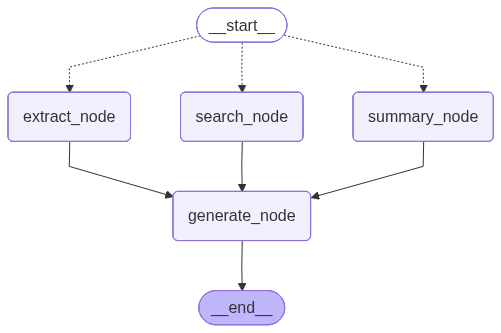

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
